In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize

In [2]:
df = pd.read_csv("cardiovascular_disease_dataset.csv")
df = df.loc[df["gender"] == 0]
df = df[["patientid", "age", "chestpain", "exerciseangia", "maxheartrate", "restingBP", "target"]]
df

,patientid,age,chestpain,exerciseangia,maxheartrate,restingBP,target
9,192523,61,0,0,150,190,1
10,201030,59,1,1,151,190,1
16,236763,42,3,0,110,137,1
22,327110,24,0,1,91,136,0
28,417218,72,2,1,119,126,1
...,...,...,...,...,...,...,...
984,9819009,33,0,1,130,124,0
989,9876043,56,0,1,188,142,0
990,9888918,63,1,1,96,196,1
992,9911700,77,0,1,142,183,1


In [3]:
df_X = df[["patientid", "age", "chestpain", "exerciseangia", "maxheartrate", "restingBP"]]
df_y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size = 0.25, train_size = 0.75, random_state=None, shuffle=True, stratify=None)

In [4]:
def sigmoid(z):
    if isinstance(z, np.ndarray):
        return 1 / (1 + np.exp(-z))
    else:
        return 1 / (1 + math.exp(-z))

def logistic_prob(theta_0, theta_1, theta_2, x_1, x_2):
    """Return probability of y=1 given x_1 and x_2."""
    ### YOUR CODE STARTS HERE ###

    linreg = theta_0 + theta_1*x_1 + theta_2*x_2

    prob_y1 = sigmoid(linreg)
    

    ### YOUR CODE ENDS HERE ###

    return prob_y1

def logistic_loss(theta_0, theta_1, theta_2, x_1, x_2, y):
    """Compute the cross-entropy loss for logistic regression."""
    ### YOUR CODE STARTS HERE ###
    prob_y1 = logistic_prob(theta_0, theta_1, theta_2, x_1, x_2)
    prob_y0 = 1 - prob_y1
    n = len(x_1)

    cross_entropy = (-np.sum(y * np.log(prob_y1)) - np.sum(np.abs(1-y) * np.log(prob_y0))) / n

    ### YOUR CODE ENDS HERE ###

    return cross_entropy

x_1 = np.asarray(df["maxheartrate"])
x_2 = np.asarray(df["restingBP"])
y_full = np.asarray(df["target"])

std_x_1 = (x_1 - x_1.mean()) / x_1.std()
std_x_2 = (x_2 - x_2.mean()) / x_2.std()

loss_function = lambda thetas: logistic_loss(thetas[0], thetas[1], thetas[2],
                                              x_1=std_x_1, x_2=std_x_2, y=y_full)

bound = 20
initial_parameter_value = np.array([0.0, 0.0, 0.0])

r = minimize(loss_function, initial_parameter_value, 
             bounds=[(-bound, bound) for _ in range(3)])
optimal_thetas = r.x

print("theta_0={}, theta_1={}, theta_2={}".format(*optimal_thetas))

theta_0=0.30161923673615865, theta_1=0.1978838774554687, theta_2=0.7095635323954115


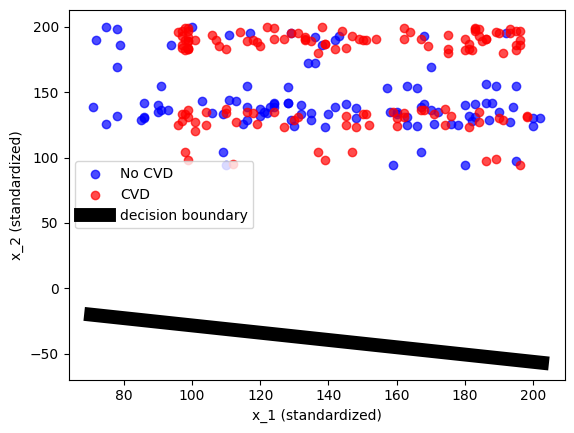

In [16]:
fig, axes = plt.subplots()


axes.scatter(x_1[y_full == 0], x_2[y_full == 0], c='blue', label='No CVD', alpha=0.7)
axes.scatter(x_1[y_full == 1], x_2[y_full == 1], c='red', label='CVD', alpha=0.7)

xs = np.linspace(x_1.min() - 0.5, x_1.max() + 0.5)
if abs(optimal_thetas[2]) > 1e-12:
    ys = -(optimal_thetas[0] + optimal_thetas[1] * xs) / optimal_thetas[2]
    axes.plot(xs, ys, 'k-', linewidth=10, label='decision boundary')

axes.set_xlabel('x_1 (standardized)')
axes.set_ylabel('x_2 (standardized)')
#axes.set_xlim(x_1.min() - 10, x_1.max() + 10)
#axes.set_ylim(x_2.min() - 10, x_2.max() + 10)
axes.legend()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a821b658-b50e-44ad-b86f-d4439f0bec8a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>